# 1 Importing Libraries





In [1]:
# Access Google Drive:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!pip install scipy keras scikeras scikit-learn pandas-market-calendars
!pip install -U pip setuptools wheel
!pip install easyesn --no-deps

In [3]:
import os, glob, site

candidates = site.getsitepackages() + [site.getusersitepackages()]

target_file = None
for base in candidates:
    pattern = os.path.join(base, "easyesn", "backend", "numpyBackend.py")
    matches = glob.glob(pattern)
    if matches:
        target_file = matches[0]
        break

if target_file is None:
    raise FileNotFoundError("Not found easyesn/backend/numpyBackend.py")

print("File found:", target_file)

with open(target_file, "r", encoding="utf-8") as f:
    text = f.read()

old = "from scipy.sparse.linalg.eigen.arpack.arpack import ArpackNoConvergence"
new = "from scipy.sparse.linalg import ArpackNoConvergence"

if old in text:
    text = text.replace(old, new)
    with open(target_file, "w", encoding="utf-8") as f:
        f.write(text)
    print("Patch applied successfully.")
else:
    print("Already fixed or path not found — current content snippet:")
    # Help debug if the import line looks different
    for line in text.splitlines():
        if "ArpackNoConvergence" in line:
            print(" ", line)

File found: /usr/local/lib/python3.13/dist-packages/easyesn/backend/numpyBackend.py
Patch applied successfully.


In [4]:
# =========================
# Basic Python / utilities
# =========================
from functools import reduce
from datetime import datetime
from os.path import exists
import gc
import io
import sys
import copy
import math
import datetime as dt
import datetime
import pandas as pd
import numpy as np
import dill
import itertools

# Jupyter
%matplotlib inline

# =========================
# Data / plotting
# =========================
import matplotlib.pyplot as plt
from matplotlib import pyplot

from numpy import array, split
from numpy.linalg import solve
from numpy.random import seed
from tabulate import tabulate
from scipy.sparse.linalg import eigsh, eigs


# =========================
# sklearn
# =========================
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import linear_model, ensemble
from sklearn.feature_selection import RFE #using recursive feature elimination to rank features
from sklearn.feature_selection import RFECV
from sklearn.svm import SVR
from sklearn.svm import LinearSVR
from sklearn.model_selection import TimeSeriesSplit

# old: from sklearn.externals import joblib
import joblib
import joblib
import copy

# =========================
# TensorFlow / Keras
# =========================
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Flatten,
    LSTM,
    GRU,
    Dropout,
    LeakyReLU
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras import optimizers
from tensorflow.keras.layers import Input

# sklearn wrapper for Keras
from scikeras.wrappers import KerasRegressor

# =========================
# Other ML packages
# =========================
from lightgbm import LGBMRegressor
import pickle

# =========================
# Finance / market calendar
# =========================
import yfinance as yf
import pandas_market_calendars as mcal

# =========================
# ESN
# =========================
from easyesn import PredictionESN
from easyesn import PredictionESN
from easyesn.optimizers import GridSearchOptimizer

# =========================
# Compatibility
# =========================
from past.builtins import xrange


# =========================
# RANDOMNESS SEED
# =========================
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


Using Numpy backend.


# 2 Data Related Functions:

In [5]:
# We first need to find the dates NYSE is open.
def date_generator(start,end):
    nyse = mcal.get_calendar('NYSE')
    a = nyse.schedule(start_date=start, end_date=end)
    a = a['market_open']
    dates = []
    timestamp = []
    for i in range(len(a)):
      dates.append(datetime.datetime.date(a[i]))
      timestamp.append(datetime.datetime.timestamp(a[i]))
    return np.asarray(dates), np.asarray(timestamp)

In [6]:
# Access to previosly prepared macro variables by sectors:
def importData(sector):


  if sector == 'HealthCare':
    filename = 'healthcare.csv'
  elif sector == 'Communication_services':
    filename = 'communication_services.csv'

  elif sector == 'Energy':
    filename = 'energy.csv'

  elif sector == 'Finance':
    filename = 'financial_services.csv'

  elif sector == 'Industrial':
    filename = 'industrials.csv'

  elif sector == 'ConsumerGoods_stable':
    filename = 'consumer_goods_stable.csv'

  elif sector == 'ConsumerGoods_discretionary':
    filename = 'consumer_goods_discretionary.csv'

  elif sector == 'Technology':
    filename = 'technology.csv'

  elif sector == 'Utilities':
    filename = 'utilities.csv'

  elif sector == 'Communication_services':
    filename = 'communication_services.csv'

  path =  "/content/drive/MyDrive/Summer 2026 COST 2/Sector Data/"

  full_path = path + filename

  df_new = pd.read_csv(full_path)
  df_new['Time'] = pd.to_datetime(df_new['date'])

  date, time = date_generator('2010-01-04','2026-01-01')
  t = pd.to_datetime(date)

  df_new = df_new[df_new['Time'].isin(list(t.strftime('%Y-%m-%d')))] #only accounting for trading days

  return df_new
# daily frequency

In [7]:
def get_price_return_history(tic):
    path = "/content/drive/MyDrive/Summer 2026 COST 2/Price History Data/"
    full_path = path + "_all_stocks_price_history.csv"

    # Load the new price history data
    tic_data = pd.read_csv(full_path)

    # Ensure the 'Time' column is in datetime format for merging
    tic_data['Time'] = pd.to_datetime(tic_data['date'])

    # Generate the standard trading days
    df_tic = pd.DataFrame()
    date, _ = date_generator('2016-01-01', '2026-01-01')
    df_tic['Time'] = pd.to_datetime(date)

    # Merge the specific ticker's data from the history file
    df_tic = df_tic.merge(
        tic_data[['Time', tic]],
        on='Time',
        how='left'
    )

    # Format 'Time' back to string and rename column to 'Price' as expected by the loop
    df_tic['Time'] = df_tic['Time'].dt.strftime('%Y-%m-%d')
    df_tic.rename(columns={tic: 'Price'}, inplace=True)

    # Get price return by day
    df_tic['Daily Return'] = df_tic['Price'].pct_change()
    df_tic.dropna(inplace=True)

    return df_tic

In [8]:
def prep_dat(d, n_step, n_ahead):
    # Train a network for every step ahead (4 quarters, 8 quarters)
    # Prepare data for input/output of NNs, n_step is number of historical time steps (days) to include in regression task
    # to predict next quarter cash flows, assuming 90 days in a quarter

    a = d.copy()

    for i in range(1, n_step):
        ind = "t+" + str(i)
        a[ind] = a.iloc[:, 0].shift(-i)  # Use n_step historical observations to predict next quarter

    a["Q_Next"] = a.iloc[:, 0].shift(-(n_step + n_ahead-1))  # Next quarter(s) prediction

    a.dropna(inplace=True)  # last (n_step + n_ahead) rows will be NANs since shifting forward for "Next Quarter" Variable

    return (a)

In [9]:
# Applies prep_data on all variables:
def trans_dat(data,n_s,n_a):
    pre_col = 0
    for col in data.columns[:-1]:
        if pre_col == 0:
            sup_dat = prep_dat(data[[col]],n_s,n_a).drop(columns='Q_Next').values
            sup_dat = np.expand_dims(sup_dat,axis=2)
            pre_col = col
        else:

            sup_dat1 = prep_dat(data[[col]],n_s,n_a).drop(columns='Q_Next').values
            sup_dat1 = np.expand_dims(sup_dat1,axis=2)
            sup_dat = np.concatenate((sup_dat,sup_dat1),axis=2)

    return sup_dat

In [10]:
def TrainTestSplit(dataset, n_s, n_a, n_train):
    X_new = trans_dat(dataset, n_s, n_a)
    y = prep_dat(pd.DataFrame(dataset['Daily Return']), n_s, n_a)['Q_Next']
    X_train, X_test = X_new[:n_train], X_new[n_train:]
    y_train, y_test = y.iloc[:n_train], y.iloc[n_train:]
    X_train = X_train.reshape(X_train.shape[0], -1)
    X_test  = X_test.reshape(X_test.shape[0], -1)
    return X_train, X_test, y_train, y_test

In [11]:
def TrainTestSplit_NN(dataset, n_s, n_a, n_train):
    X_new = trans_dat(dataset, n_s, n_a)
    y = prep_dat(pd.DataFrame(dataset['Daily Return']), n_s, n_a)['Q_Next']
    y_new = np.expand_dims(y, axis=1)
    return X_new[:n_train], X_new[n_train:], y_new[:n_train], y_new[n_train:]

In [12]:
# Clean & Use Monthly Bloomberg S&P100 Constituent Data
MONTH_NUM_TO_NAME = {
    1: "January", 2: "February", 3: "March", 4: "April",
    5: "May", 6: "June", 7: "July", 8: "August",
    9: "September", 10: "October", 11: "November", 12: "December"
}

def _bloomberg_to_standard(bbg_ticker: str) -> str:
    """'AAPL UW Equity' → 'AAPL', 'BRK/B UN Equity' → 'BRK.B'."""
    symbol = bbg_ticker.split()[0]
    return symbol.replace("/", ".")


def get_constituents_for_period(year, month):
    """
    Load S&P 100 constituents for a specific month.

    Parameters:
        year: int (e.g. 2023)
        month: int (1-12)

    Returns: list of ticker strings
    """
    month_name = MONTH_NUM_TO_NAME[month]
    path = f"/content/drive/MyDrive/Summer 2026 COST 2/S&P100 Monthly Constituents/{year}/{month_name}.xlsx"
    df = pd.read_excel(path, engine="openpyxl")

    df['Ticker'] = df['Ticker'].apply(_bloomberg_to_standard)

    # Drop  9903115D
    df = df[df['Ticker'] != '9903115D']

    # Convert Bloomberg tickers to standard use
    return df['Ticker'].tolist()

def build_pit_lookup(start_date, end_date, strict=True):
    lookup, missing = {}, []
    current = pd.Timestamp(start_date).to_period('M')
    end = pd.Timestamp(end_date).to_period('M')
    while current <= end:
        try:
            lookup[(current.year, current.month)] = set(
                get_constituents_for_period(current.year, current.month))
        except FileNotFoundError:
            lookup[(current.year, current.month)] = set()
            missing.append(str(current))
        current += 1
    if missing:
        msg = f"No S&P100 constituent file for {len(missing)} month(s): {missing}"
        if strict:
            raise FileNotFoundError(msg)
        print("WARNING:", msg)
    return lookup

# 3 Model Related Functions:

In [13]:
def root_mean_squared_error(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_pred - y_true)))

In [14]:
def ridge(test_index,train_index,X_train, X_test, y_train, y_test):
  # normalize the dataset
  scaler1 = MinMaxScaler(feature_range=(0, 1))
  scaler2 = MinMaxScaler(feature_range=(0, 1))
  #scaler1 = StandardScaler()
  #scaler2 = StandardScaler()
  X_train = scaler1.fit_transform(X_train)
  X_test = scaler1.transform(X_test)
  y_train = scaler2.fit_transform(np.expand_dims(y_train, axis=1))
  y_test = scaler2.transform(np.expand_dims(y_test, axis=1))

  #ols = linear_model.LinearRegression(n_jobs = -1)
  ols = linear_model.Ridge(alpha=10.0)
  ols.fit(X_train, y_train)


  y_test = scaler2.inverse_transform(y_test)
  y_train = scaler2.inverse_transform(y_train)

  y_pred = ols.predict(X_test)


  #y_pred = scaler2.inverse_transform(y_pred)
  y_pred = scaler2.inverse_transform(y_pred.reshape(-1, 1))

  r2_test = r2_score(y_test,y_pred)

  # mean_squared_error has no "squared" parameter anymore
  # rmse_test = mean_squared_error(y_test, y_pred, squared = False)
  rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))

  rmse = np.sqrt(mean_squared_error(y_test, y_pred))
  y_pred_train = ols.predict(X_train)

  y_pred_train = scaler2.inverse_transform(y_pred_train.reshape(-1,1))
  r2_train = r2_score(y_train, y_pred_train)
  rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

  return ols,y_pred,y_pred_train,rmse,r2_test,rmse_test,r2_train,rmse_train

In [15]:
def echo_state(test_index,train_index,X_train, X_test, y_train, y_test):

  # normalize the dataset
  scaler1 = MinMaxScaler(feature_range=(0, 1))
  scaler2 = MinMaxScaler(feature_range=(0, 1))
  #scaler1 = StandardScaler()
  #scaler2 = StandardScaler()
  X_train = scaler1.fit_transform(X_train)
  X_test = scaler1.transform(X_test)
  y_train = scaler2.fit_transform(np.expand_dims(y_train, axis=1))
  y_test = scaler2.transform(np.expand_dims(y_test, axis=1))

  keras.backend.clear_session()

  np.random.seed(SEED)

  esn = PredictionESN(n_input=X_train.shape[1], n_output=1,n_reservoir=100,leakingRate=0.5, regressionParameters=[10e-1], solver="lsqr", feedback=True,        spectralRadius=1.0,
        noiseLevel=0.0,
        inputScaling=None,
        feedbackScaling=1.0,
        reservoirDensity=0.5)

  esn.fit(X_train, y_train, transientTime=0,verbose=0)

  y_test = scaler2.inverse_transform(y_test)
  y_train = scaler2.inverse_transform(y_train)
  y_pred = esn.predict(X_test)
  y_pred = scaler2.inverse_transform(y_pred)

  r2_test = r2_score(y_test,y_pred)
  rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
  rmse = np.sqrt(mean_squared_error(y_test, y_pred))
  y_pred_train = esn.predict(X_train)
  y_pred_train = scaler2.inverse_transform(y_pred_train)
  r2_train = r2_score(y_train, y_pred_train)
  rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

  return esn,y_pred,y_pred_train,rmse,r2_test,rmse_test,r2_train,rmse_train

In [16]:
def lstm(test_index,train_index,X_train, X_test, y_train, y_test):

  # normalize the dataset
  scaler1 = MinMaxScaler(feature_range=(0, 1))
  scaler2 = MinMaxScaler(feature_range=(0, 1))
  X_train = scaler1.fit_transform(X_train.reshape(X_train.shape[0],X_train.shape[1]*X_train.shape[2])).reshape(X_train.shape[0],X_train.shape[1],X_train.shape[2])
  X_test = scaler1.transform(X_test.reshape(X_test.shape[0],X_test.shape[1]*X_test.shape[2])).reshape(X_test.shape[0],X_test.shape[1],X_test.shape[2])
  y_train = scaler2.fit_transform(y_train)
  y_test = scaler2.transform(y_test)

  keras.backend.clear_session()
  tf.random.set_seed(SEED)

  model = Sequential()
  model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
  model.add(LSTM(16, activation='relu', kernel_initializer='random_normal', return_sequences=False))
  model.add(Dense(256, activation='relu',kernel_initializer='random_normal'))
  #model.add(Dense(128,activation='relu',kernel_initializer='random_normal'))
  model.add(Dense(64, activation='relu',kernel_initializer='random_normal'))
  model.add(Dense(1,activation='linear',kernel_initializer='random_normal'))

  model.compile(loss=root_mean_squared_error, optimizer=optimizers.Adam(learning_rate=0.001))
  history = model.fit(X_train,y_train,validation_split=0.001, epochs=250, callbacks=[EarlyStopping(monitor='loss',mode='min', patience=50)], verbose=0, shuffle=False)

  y_test = scaler2.inverse_transform(y_test)
  y_train = scaler2.inverse_transform(y_train)

  y_pred = model.predict(X_test, verbose=0)
  y_pred = scaler2.inverse_transform(y_pred)

  r2_test = r2_score(y_test,y_pred)
  rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))

  rmse = np.sqrt(mean_squared_error(y_test, y_pred))
  y_pred_train = model.predict(X_train, verbose=0)
  y_pred_train = scaler2.inverse_transform(y_pred_train)
  r2_train = r2_score(y_train, y_pred_train)
  rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

  return model,y_pred,y_pred_train,rmse,r2_test,rmse_test,r2_train,rmse_train


In [17]:
def gru(test_index,train_index,X_train, X_test, y_train, y_test):

  # normalize the dataset
  scaler1 = MinMaxScaler(feature_range=(0, 1))
  scaler2 = MinMaxScaler(feature_range=(0, 1))
  X_train = scaler1.fit_transform(X_train.reshape(X_train.shape[0],X_train.shape[1]*X_train.shape[2])).reshape(X_train.shape[0],X_train.shape[1],X_train.shape[2])
  X_test = scaler1.transform(X_test.reshape(X_test.shape[0],X_test.shape[1]*X_test.shape[2])).reshape(X_test.shape[0],X_test.shape[1],X_test.shape[2])
  y_train = scaler2.fit_transform(y_train)
  y_test = scaler2.transform(y_test)

  model = Sequential()
  model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
  model.add(GRU(32, activation='relu'))
  # model.add(LeakyReLU(alpha=l_alpha))
  model.add(Dense(256, activation='relu'))
  #model.add(Dense(128, activation='relu'))
  model.add(Dense(64, activation='relu'))
  model.add(Dense(1,activation='relu'))
  #sgd = optimizers.SGD(lr=0.001, decay=1e-7, momentum=0.9, nesterov=True)

  model.compile(loss=root_mean_squared_error, optimizer=optimizers.Adam(learning_rate=0.0001))
  history = model.fit(X_train,y_train, validation_split=0.001, epochs=250, callbacks=[EarlyStopping(monitor='val_loss', mode='min',patience=100)], verbose=0, shuffle=False)

  y_test = scaler2.inverse_transform(y_test)
  y_train = scaler2.inverse_transform(y_train)

  y_pred = model.predict(X_test, verbose=0)
  y_pred = scaler2.inverse_transform(y_pred)

  r2_test = r2_score(y_test,y_pred)
  rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))

  rmse = np.sqrt(mean_squared_error(y_test, y_pred))
  y_pred_train = model.predict(X_train, verbose=0)
  y_pred_train = scaler2.inverse_transform(y_pred_train)
  r2_train = r2_score(y_train, y_pred_train)
  rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

  return model,y_pred,y_pred_train,rmse,r2_test,rmse_test,r2_train,rmse_train


# 4 Tabulating and plotting functions

In [18]:
def top_four_returns(a, b):  # a from real, b from prediction
    x = []
    for i in range(len(a)):
        cols = b.loc[b.index[i], :].values[1:]
        x.append(np.nanmean(a.loc[a.index[i], cols].values))  # nanmean instead of mean
    top_four = pd.DataFrame(x)
    cum_returns_test_top_four = (top_four + 1).cumprod()
    return top_four, cum_returns_test_top_four

In [19]:
def top_four_returns_by_model(model, data_test, data_train,
                               returns_test_pred, returns_train_pred):
    # testing data:
    returns_test = returns_test_pred[model].fillna(0)
    test_sectors = pd.DataFrame(
        returns_test.columns.values[np.argsort(-returns_test.values, axis=1)[:, :4]],
        index=returns_test.index,
        columns=['1st Max', '2nd Max', '3rd Max', '4th Max']
    ).reset_index()

    test_top_four, test_top_four_cum = top_four_returns(data_test, test_sectors)

    # training data:
    returns_train = returns_train_pred[model].fillna(0)
    train_sectors = pd.DataFrame(
        returns_train.columns.values[np.argsort(-returns_train.values, axis=1)[:, :4]],
        index=returns_train.index,
        columns=['1st Max', '2nd Max', '3rd Max', '4th Max']
    ).reset_index()

    train_top_four, train_top_four_cum = top_four_returns(data_train, train_sectors)
    return test_top_four, test_top_four_cum, train_top_four, train_top_four_cum

In [20]:
def benchmark_stats(returns, cum_returns, freq):
    if freq[-1] == 'M':
        n = 12
    elif freq[-1] == 'D':
        n = 252
    elif freq[-1] == 'Q':
        n = 4

    # Flatten Series / 1-col DataFrames / arrays down to 1-D
    returns = np.asarray(returns, dtype=float).ravel()
    cum = np.asarray(cum_returns, dtype=float).ravel()

    final_cum = cum[-1]
    if final_cum <= 0:
        annualized_rate = -1.0          # total loss; avoids nan from negative^fraction
    else:
        annualized_rate = np.power(final_cum, n / len(cum)) - 1
    #print("annualized return", annualized_rate)

    mean_return = np.nanmean(returns)
    std_return = np.nanstd(returns)
    #print("mean return", mean_return)
    #print("std return", std_return)
    annualized_sharpe = (mean_return / std_return) * np.sqrt(n) if std_return > 0 else np.nan
    #print("annualized sharpe", annualized_sharpe)

    peak = np.maximum.accumulate(cum)
    dd = (cum / peak) - 1
    max_dd = np.abs(np.nanmin(dd))
    #print("max drawdown", max_dd)
    annualized_calmar = annualized_rate / max_dd if max_dd > 0 else np.nan
    #print("annualized calmar", annualized_calmar)

    return annualized_rate, annualized_sharpe, float(annualized_calmar)

In [21]:
def build_sector_detail(pred_by_tic_df, actual_by_tic_df, pit_lookup, tic_sector_dict, n_top=4):
    """Returns per-period detail: sector predicted returns, constituent-level detail,
    selected portfolio sectors, and the best-forecast ranking."""
    all_sectors = sorted(set(tic_sector_dict.values()))
    constituent_rows = []          # Date, Sector, Ticker, Pred, Actual
    portfolio_rows   = []          # Date, Rank, Sector, Pred (top-n only)
    ranking_rows     = []          # Date, Sector, Pred, Rank (all eligible sectors)

    for ts in pred_by_tic_df.index:
        t = pd.Timestamp(ts)
        eligible = pit_lookup.get((t.year, t.month), set())

        # equal-weight sector prediction from eligible constituents
        sector_pred = {}
        for sector in all_sectors:
            tics = [c for c in pred_by_tic_df.columns
                    if tic_sector_dict.get(c) == sector and c in eligible]
            if not tics:
                continue
            sector_pred[sector] = pred_by_tic_df.loc[ts, tics].mean()
            for c in tics:
                constituent_rows.append({
                    'Date': t, 'Sector': sector, 'Ticker': c,
                    'Predicted Return': pred_by_tic_df.loc[ts, c],
                    'Actual Return': actual_by_tic_df.loc[ts, c] if c in actual_by_tic_df.columns else np.nan,
                })

        # rank sectors by predicted return (best-forecast) and mark portfolio picks
        ranked = sorted(sector_pred.items(), key=lambda kv: kv[1], reverse=True)
        for rank, (sector, pred) in enumerate(ranked, start=1):
            ranking_rows.append({'Date': t, 'Sector': sector,
                                 'Predicted Return': pred, 'Rank': rank})
            if rank <= n_top:
                portfolio_rows.append({'Date': t, 'Rank': rank,
                                       'Sector': sector, 'Predicted Return': pred})

    return (pd.DataFrame(constituent_rows),
            pd.DataFrame(portfolio_rows),
            pd.DataFrame(ranking_rows))

In [22]:
def sector_comparison(metrics_dict, actual_df, pred_data, all_sectors, model_list):
        rows = {}
        for sector in all_sectors:
            sector_tics = [t for t in metrics_dict if tic_sector_dict.get(t) == sector]
            row = {}
            for model in model_list:
                # RMSE: mean of stock-level RMSE across this sector's constituents
                rmse_vals = [metrics_dict[t][model]['RMSE']
                             for t in sector_tics
                             if isinstance(metrics_dict[t][model], dict)]
                row[f'{model} RMSE'] = np.nanmean(rmse_vals) if rmse_vals else np.nan
                # R-Squared: on the aligned equal-weighted sector series
                if sector in actual_df.columns and sector in pred_data[model].columns:
                    m = pd.concat([actual_df[sector], pred_data[model][sector]], axis=1).dropna()
                    row[f'{model} R-Squared'] = (
                        r2_score(m.iloc[:, 0], m.iloc[:, 1]) if len(m) >= 2 else np.nan
                    )
                else:
                    row[f'{model} R-Squared'] = np.nan
            row['# constituents'] = len(sector_tics)
            rows[sector] = row
        return pd.DataFrame(rows).T


In [23]:
def sector_pred_vs_actual(actual_df, pred_df, n_top=4, as_pct=True):
    """One row per sector: forecast quality and top-n selection agreement.

    Only (month, sector) cells where both actual and predicted exist are used, so
    the predicted and actual top-n sets are always drawn from the same universe.
    """
    both = actual_df.notna() & pred_df.notna()
    a, p = actual_df.where(both), pred_df.where(both)

    def top_mask(df):
        # method='first' guarantees exactly n_top winners per row even on ties
        return df.rank(axis=1, ascending=False, method='first').le(n_top) & df.notna()

    pred_top, actual_top = top_mask(p), top_mask(a)
    periods = both.sum()
    scale = 100.0 if as_pct else 1.0

    return pd.DataFrame({
        'periods':          periods,
        'periods_pred_top': (pred_top & both).sum(),
        'periods_act_top':  (actual_top & both).sum(),
        'hit_rate':         ((pred_top == actual_top) & both).sum() / periods.replace(0, np.nan),
        'pred_mean_%':      p.mean() * scale,
        'actual_mean_%':    a.mean() * scale,
        'pred_sd_%':        p.std()  * scale,
        'actual_sd_%':      a.std()  * scale,
        'MAE_%':            (p - a).abs().mean() * scale,
    }).sort_index()

# 5 Feature Selection

### Feature Selection Functions

In [24]:
def top_n_features(n, X, selector):
  features = list()
  for i in range(len(selector.ranking_)):
    if selector.ranking_[i] <= n:
      features.append(X.columns[i])
  return features


In [25]:
# Feature Selection Function:
def feature_selection(group_by_freq, data_features, data_tic,tic,companyname):
  if group_by_freq!='1D':
    data_features = data_features.set_index('Time').groupby(pd.Grouper(freq=group_by_freq)).last().reset_index()
    data_tic['Time'] = pd.to_datetime(data_tic['Time'])
    data_tic = data_tic.set_index('Time').groupby(pd.Grouper(freq=group_by_freq)).last().reset_index()
# ── Align to shared dates ──
  merged = data_features.merge(data_tic[['Time', 'Daily Return']], on='Time', how='inner')
  merged.dropna(subset=['Daily Return'], inplace=True)

  time_index = merged['Time']
  X = merged.drop(['Time', 'date', 'Daily Return'], axis=1)
  X = X.reset_index(drop=True)
  X = X.dropna(axis=1, how='all')
  X_copy = X.copy()

  y = merged['Daily Return'].reset_index(drop=True)



  estimator = ensemble.RandomForestRegressor(random_state=SEED)
  tscv = TimeSeriesSplit() #Cross validation
  selector = RFECV(estimator=estimator, step=1, cv=tscv, verbose=0,scoring='r2')

  # Feature selection on the TRAINING FOLD ONLY (no test-period leakage).
  # Mirrors the 0.225 hold-out used later in market_indicators_experiment.
  test_size = 0.225
  n_train = int(np.floor((1 - test_size) * len(X)))
  selector.fit(X.iloc[:n_train], y.iloc[:n_train])



  ################Create dset for plotting
  dset = pd.DataFrame()
  print(np.where(selector.support_ == False)[0])#[True, False, True, False, True]not important is False
  X_copy.drop(X_copy.columns[np.where(selector.support_ == False)[0]], axis=1, inplace=True)#inplace=True change on original object
  dset['attr'] = X_copy.columns
  print(selector.estimator_.feature_importances_)
  dset['importance'] = selector.estimator_.feature_importances_
  dset = dset.sort_values(by='importance', ascending=False)

  fig,ax=plt.subplots(figsize=(10, 6))
  plt.barh(y=dset['attr'], width=dset['importance'],color='#1976D2')
  ax.set_title('Feature Importance Using RFE on '+companyname, fontsize=16, fontweight='bold', pad=20)
  ax.set_xlabel('Feature Importance', fontsize=14)
  ax.set_facecolor('white')
  ax.spines['bottom'].set_color('black')
  ax.spines['left'].set_color('black')
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  path = "/content/drive/MyDrive/Summer 2026 COST 2/Plots/"
  plt.tight_layout()
  plt.savefig(path + 'feature_importance_' + tic + '.png')
  plt.show()

  ##############################
  print(selector.estimator_.feature_importances_)
  print('rank for columns:',selector.ranking_)#rank=1 feature that was kept in the end, rank2 feature that was deleted in the second last round
  print('Column Names:',X.columns)
  print('Ranked Features:')
  for r in range(1,max(selector.ranking_)+1):#ranking is from 0, change to from 1
    col_str = str(r) + '.'
    for i in range(len(selector.ranking_)):
      if selector.ranking_[i] == r:
        col_str = col_str + ' ' + X.columns[i]
    print(col_str)#for loop is for printing

  ##############################
  X_new = X[top_n_features(4, X, selector)]#top_n_features returns columns' names

  #get concated dataset for training
  dataset = pd.concat([X_new.reset_index().drop(columns=['index']), pd.DataFrame(y)],axis=1)

  return time_index,dataset

## Feature Selection Execution

In [26]:
#Create tic, tic-sector mapping and sector lists
sector_list = ['HealthCare','Energy','Finance','Industrial','ConsumerGoods_stable','ConsumerGoods_discretionary','Communication_services','Technology','Utilities']

path =  "/content/drive/MyDrive/Summer 2026 COST 2/Sector Data/"
df = pd.read_csv(path + "all_tickers_sector_mappings.csv")

tic_sector_dict = dict(zip(df["ticker"], df["sector"]))
tic_companyname_dict = dict(zip(df["ticker"], df["company_name"]))
print(tic_sector_dict)
print(tic_companyname_dict)

tic_list = list(tic_sector_dict.keys())

print(tic_list)
print(len(tic_list))

{'AAPL': 'Technology', 'ABBV': 'HealthCare', 'ABT': 'HealthCare', 'ACN': 'Technology', 'ADBE': 'Technology', 'AGN': 'Finance', 'AIG': 'Finance', 'ALL': 'Finance', 'AMAT': 'Technology', 'AMD': 'Technology', 'AMGN': 'HealthCare', 'AMT': 'Finance', 'AMZN': 'ConsumerGoods_discretionary', 'APA': 'Energy', 'AVGO': 'Technology', 'AXP': 'Finance', 'BA': 'Industrial', 'BAC': 'Finance', 'BIIB': 'HealthCare', 'BKNG': 'ConsumerGoods_discretionary', 'BLK': 'Finance', 'BMY': 'HealthCare', 'BNY': 'Finance', 'BRK.B': 'Finance', 'C': 'Finance', 'CAT': 'Industrial', 'CEG': 'Utilities', 'CHTR': 'Communication_services', 'CL': 'ConsumerGoods_stable', 'CMCSA': 'Communication_services', 'COF': 'Finance', 'COP': 'Energy', 'COST': 'ConsumerGoods_stable', 'CRM': 'Technology', 'CSCO': 'Technology', 'CVS': 'HealthCare', 'CVX': 'Energy', 'DD': 'Industrial', 'DE': 'Industrial', 'DHR': 'HealthCare', 'DIS': 'Communication_services', 'DOW': 'ConsumerGoods_stable', 'DUK': 'Utilities', 'DVN': 'Energy', 'EMC': 'Technolo

### ONLY RUN TO REDO RFE

In [ ]:
# Feature Importance for each sector and keep the resulting data in a list:
tic_data_list = {}
tic_dates_list = {}

save_path = "/content/drive/MyDrive/Summer 2026 COST 2/tic_data_list"
os.makedirs(save_path, exist_ok=True)


#Run RFE
for tic in tic_list:
  print('----', tic, '----')
  sector = tic_sector_dict[tic]
  time_index,dataset = feature_selection(group_by_freq = '1M',
                                        data_features = importData(sector),
                                        data_tic = get_price_return_history(tic),
                                        tic=tic,
                                        companyname = tic_companyname_dict[tic])

  #print(time_index
  dates = pd.DataFrame(time_index)
  dates = dates.reset_index(drop=True)
  tic_dates_list[tic] = dates[['Time']]
  tic_data_list[tic] = dataset

  # SAVE RFE RESULTS
  pd.concat([dates, dataset], axis=1).to_csv(
      os.path.join(save_path, f"{tic}.csv"), index=False
  )

### RUN THIS TO USED SAVED RESULTS INSTEAD OF RERUNNING RFE

In [27]:
# RUN THIS TO USED SAVED RESULTS INSTEAD OF RERUNNING RFE

path = "/content/drive/MyDrive/Summer 2026 COST 2/tic_data_list"

# Ensure path exists
os.makedirs(path, exist_ok=True)

tic_data_list = {}
tic_dates_list = {}

for tic in tic_list:
    df = pd.read_csv(os.path.join(path, f"{tic}.csv"), parse_dates=['Time'])
    tic_dates_list[tic] = df[['Time']]
    tic_data_list[tic] = df.drop(columns=['Time'])

# 6 market_indicators_experiment

## Function_market_indicators_experiment

In [28]:
def pit_sector_average_df(returns_df, tic_sector_dict, pit_lookup, n_a=1):
    """Average only stocks that were S&P100 members at the decision date,
    n_a periods before the month being predicted."""
    result_rows = []
    all_sectors = sorted(set(tic_sector_dict.values()))

    for idx, row in returns_df.iterrows():
        decision = pd.Timestamp(idx).to_period('M') - n_a
        eligible = pit_lookup.get((decision.year, decision.month), set())

        sector_avgs = {}
        for sector in all_sectors:
            tics = [t for t in returns_df.columns
                    if tic_sector_dict.get(t) == sector
                    and t in eligible
                    and pd.notna(row[t])]
            sector_avgs[sector] = row[tics].mean() if tics else np.nan
        result_rows.append(sector_avgs)

    return pd.DataFrame(result_rows, index=returns_df.index)

In [29]:
def market_indicators_experiment(group_by_freq='1M', look_back=2, look_ahead=1/12, model_list=None):

    path =  "/content/drive/MyDrive/Summer 2026 COST 2/Models/"
    path_results = "/content/drive/MyDrive/Summer 2026 COST 2/Results/"
    path_plots = "/content/drive/MyDrive/Summer 2026 COST 2/Plots/"

    if model_list is None:
          model_list = ['ESN', 'LSTM', 'GRU']
    print("Runnings models: ", model_list)

    if group_by_freq[-1] in ['d','D']:
        denominator = eval(group_by_freq[:-1])
        n_s = int(252*look_back/denominator)
        print('lookback window of this experiment: ', n_s)
        n_a = int(252*look_ahead/denominator)
        print('look ahead window of this experiment: ', n_a)
    elif group_by_freq[-1] in ['w','W']:
        denominator = eval(group_by_freq[:-1])*5
        n_s = int(252*look_back/denominator)
        print('lookback window of this experiment: ', n_s)
        n_a = int(252*look_ahead/denominator)
        print('look ahead window of this experiment: ', n_a)
    #1. group_by_freq='1M' benchmark
    elif group_by_freq[-1] in ['m','M']:
        denominator = eval(group_by_freq[:-1])#eval("1")
        n_s = int(12*look_back/denominator) #n_s = 24
        print('lookback window of this experiment: ', n_s)
        n_a = int(12*look_ahead/denominator) #n_a = 1
        print('look ahead window of this experiment: ', n_a)

    # 2. Train test split
    tic_traintest_list = {}
    tic_traintest_NN_list = {}
    train_index = {}
    test_index = {}
    active_tics = []

    MIN_TRAIN, MIN_TEST = 24, 1

    # pass 1 — per-ticker index of the months being predicted
    per_tic_index = {}
    for tic in tic_list:
        n_targets = len(tic_data_list[tic]) - (n_s + n_a - 1)
        if n_targets < MIN_TRAIN + MIN_TEST:
            print(f"Skipping {tic}: only {n_targets} usable target months")
            continue
        idx = pd.DatetimeIndex(pd.to_datetime(tic_dates_list[tic]['Time']))
        per_tic_index[tic] = idx[n_s + n_a - 1:]
    # one cutoff for everybody, derived from the data rather than hardcoded
    all_months = pd.DatetimeIndex(sorted(set().union(*(set(v) for v in per_tic_index.values()))))
    cutoff = all_months[int(np.floor((1 - 0.225) * len(all_months))) - 1]
    print(f"Global split at {cutoff.date()} over {len(all_months)} calendar months")
    # pass 2 — split every ticker on that same date
    for tic, idx in per_tic_index.items():
        n_train = int((idx <= cutoff).sum())
        n_test  = len(idx) - n_train
        if n_train < MIN_TRAIN or n_test < MIN_TEST:
            print(f"Skipping {tic}: {n_train} train / {n_test} test months")
            continue
        active_tics.append(tic)
        train_index[tic] = idx[idx <= cutoff]
        test_index[tic]  = idx[idx > cutoff]
        tic_traintest_list[tic]    = TrainTestSplit(tic_data_list[tic], n_s, n_a, n_train)
        tic_traintest_NN_list[tic] = TrainTestSplit_NN(tic_data_list[tic], n_s, n_a, n_train)


    metric_list = ['RMSE', 'R-Squared']
    benchmark_list = ['Actual'] + model_list
    stats_list = ['Annualized Return', 'Annualized Sharpe', 'Annualized Calmar']
    train_metrics = {tic: {m: {met: 0 for met in metric_list} for m in model_list} for tic in active_tics}
    test_metrics = {tic: {m: {met: 0 for met in metric_list} for m in model_list} for tic in active_tics}
    y_pred_dict = {tic: {m: 0 for m in model_list} for tic in active_tics}
    y_pred_train_dict = {tic: {m: 0 for m in model_list} for tic in active_tics}
    y_test_dict = {tic: 0 for tic in active_tics}
    y_train_dict = {tic: 0 for tic in active_tics}
    returns_test_pred_data = {m: {tic: 0 for tic in active_tics} for m in model_list}
    returns_test_data = {tic: 0 for tic in active_tics}
    returns_train_pred_data = {m: {tic: 0 for tic in active_tics} for m in model_list}
    returns_train_data = {tic: 0 for tic in active_tics}
    returns_test_top_four_data = {m: 0 for m in model_list}
    returns_train_top_four_data = {m: 0 for m in model_list}
    returns_test_top_four_cum_data = {m: 0 for m in model_list}
    returns_train_top_four_cum_data = {m: 0 for m in model_list}
    benchmark_test_stats = {b: {s: 0 for s in stats_list} for b in benchmark_list}
    benchmark_train_stats = {b: {s: 0 for s in stats_list} for b in benchmark_list}


    # 3.running models
    if 'RIDGE' in model_list:
      # 3.1 run ridge regression for each tic:
      for i, tic in enumerate(active_tics, 1):
          traintest = tic_traintest_list[tic]
          print(f"Running RIDGE on {tic} ({i}/{len(active_tics)})")
          X_train, X_test, y_train, y_test = traintest[0], traintest[1], traintest[2], traintest[3]

          model,y_pred,y_pred_train,rmse,r2_test,rmse_test,r2_train,rmse_train = ridge(test_index,train_index,X_train, X_test, y_train, y_test)
          file_name = "linear_"+tic+"_"+str(n_s)+"_"+str(n_a)+".pkl"
          #Automatically create path
          os.makedirs(path, exist_ok=True)
          joblib.dump(model,path+file_name)
          y_test_dict[tic] = y_test
          y_train_dict[tic] = y_train
          y_pred_dict[tic]['RIDGE'] = y_pred
          y_pred_train_dict[tic]['RIDGE'] = y_pred_train
          train_metrics[tic]['RIDGE']['RMSE']=rmse_train
          train_metrics[tic]['RIDGE']['R-Squared']=r2_train
          test_metrics[tic]['RIDGE']['RMSE']=rmse_test
          test_metrics[tic]['RIDGE']['R-Squared']=r2_test

      ridge_test_frames = {}
      ridge_train_frames = {}
      for tic in active_tics:
          ridge_test_frames[tic] = pd.Series(
              y_pred_dict[tic]['RIDGE'].flatten(),
              index=test_index[tic]
          )
          ridge_train_frames[tic] = pd.Series(
              y_pred_train_dict[tic]['RIDGE'].flatten(),
              index=train_index[tic]
          )
      ridge_test = pd.DataFrame(ridge_train_frames)
      ridge_train = pd.DataFrame(ridge_train_frames)

      ridge_test.to_csv(path_results+'ridge_test_results'+str(n_s)+'_'+str(n_a)+'.csv')
      ridge_train.to_csv(path_results+'ridge_train_results'+str(n_s)+'_'+str(n_a)+'.csv')


    if 'ESN' in model_list:
      # 3.2 run echo state networks for each tic:
      for i, tic in enumerate(active_tics, 1):
          traintest = tic_traintest_list[tic]
          print(f"Running ESN on {tic} ({i}/{len(active_tics)})")
          X_train, X_test, y_train, y_test = traintest[0], traintest[1], traintest[2], traintest[3]

          esn,y_pred,y_pred_train,rmse,r2_test,rmse_test,r2_train,rmse_train = echo_state(test_index,train_index,X_train, X_test, y_train, y_test)
          file_name = "esn_"+tic+"_"+str(n_s)+"_"+str(n_a)+".pkl"
          with open(path+file_name, 'wb') as file:
              dill.dump(esn, file)
          y_test_dict[tic] = y_test
          y_train_dict[tic] = y_train
          y_pred_dict[tic]['ESN'] = y_pred
          y_pred_train_dict[tic]['ESN'] = y_pred_train
          train_metrics[tic]['ESN']['RMSE']=rmse_train
          train_metrics[tic]['ESN']['R-Squared']=r2_train
          test_metrics[tic]['ESN']['RMSE']=rmse_test
          test_metrics[tic]['ESN']['R-Squared']=r2_test

      esn_test_frames = {}
      esn_train_frames = {}
      for tic in active_tics:
          esn_test_frames[tic] = pd.Series(
              y_pred_dict[tic]['ESN'].flatten(),
              index=test_index[tic]
          )
          esn_train_frames[tic] = pd.Series(
              y_pred_train_dict[tic]['ESN'].flatten(),
              index=train_index[tic]
          )
      esn_test = pd.DataFrame(esn_test_frames)
      esn_train = pd.DataFrame(esn_train_frames)

      esn_test.to_csv(path_results+'esn_test_results'+str(n_s)+'_'+str(n_a)+'.csv')
      esn_train.to_csv(path_results+'esn_train_results'+str(n_s)+'_'+str(n_a)+'.csv')

    if 'LSTM' in model_list:
      # 3.3 run lstm for each tic:
      for i, tic in enumerate(active_tics, 1):
          traintest = tic_traintest_NN_list[tic]
          X_train, X_test, y_train, y_test = traintest[0], traintest[1], traintest[2], traintest[3]
          print(f"Running LSTM on {tic} ({i}/{len(active_tics)})")
          model,y_pred,y_pred_train,rmse,r2_test,rmse_test,r2_train,rmse_train = lstm(test_index,train_index,X_train, X_test, y_train, y_test)
          file_name = "lstm_"+tic+"_"+str(n_s)+"_"+str(n_a)+".keras"
          model.save(path+file_name)
          y_test_dict[tic] = y_test
          y_train_dict[tic] = y_train
          y_pred_dict[tic]['LSTM'] = y_pred
          y_pred_train_dict[tic]['LSTM'] = y_pred_train
          train_metrics[tic]['LSTM']['RMSE']=rmse_train
          train_metrics[tic]['LSTM']['R-Squared']=r2_train
          test_metrics[tic]['LSTM']['RMSE']=rmse_test
          test_metrics[tic]['LSTM']['R-Squared']=r2_test

      lstm_test_frames = {}
      lstm_train_frames = {}
      for tic in active_tics:
          lstm_test_frames[tic] = pd.Series(
              y_pred_dict[tic]['LSTM'].flatten(),
              index=test_index[tic]
          )
          lstm_train_frames[tic] = pd.Series(
              y_pred_train_dict[tic]['LSTM'].flatten(),
              index=train_index[tic]
          )
      lstm_test = pd.DataFrame(lstm_test_frames)
      lstm_train = pd.DataFrame(lstm_train_frames)

      lstm_test.to_csv(path_results+'lstm_test_results'+str(n_s)+'_'+str(n_a)+'.csv')
      lstm_train.to_csv(path_results+'lstm_train_results'+str(n_s)+'_'+str(n_a)+'.csv')

    if 'GRU' in model_list:
      # 3.4 run gru for each tic:
      for i, tic in enumerate(active_tics, 1):
          traintest = tic_traintest_NN_list[tic]
          X_train, X_test, y_train, y_test = traintest[0], traintest[1], traintest[2], traintest[3]
          print(f"Running GRU on {tic} ({i}/{len(active_tics)})")
          model,y_pred,y_pred_train,rmse,r2_test,rmse_test,r2_train,rmse_train = gru(test_index,train_index,X_train, X_test, y_train, y_test)
          file_name = "gru_"+tic+"_"+str(n_s)+"_"+str(n_a)+".keras"
          model.save(path+file_name)
          y_test_dict[tic] = y_test
          y_train_dict[tic] = y_train
          y_pred_dict[tic]['GRU'] = y_pred
          y_pred_train_dict[tic]['GRU'] = y_pred_train
          train_metrics[tic]['GRU']['RMSE']=rmse_train
          train_metrics[tic]['GRU']['R-Squared']=r2_train
          test_metrics[tic]['GRU']['RMSE']=rmse_test
          test_metrics[tic]['GRU']['R-Squared']=r2_test

      gru_test_frames = {}
      gru_train_frames = {}
      for tic in active_tics:
          gru_test_frames[tic] = pd.Series(
              y_pred_dict[tic]['GRU'].flatten(),
              index=test_index[tic]
          )
          gru_train_frames[tic] = pd.Series(
              y_pred_train_dict[tic]['GRU'].flatten(),
              index=train_index[tic]
          )
      gru_test = pd.DataFrame(gru_test_frames)
      gru_train = pd.DataFrame(gru_train_frames)

      gru_test.to_csv(path_results+'gru_test_results'+str(n_s)+'_'+str(n_a)+'.csv')
      gru_train.to_csv(path_results+'gru_train_results'+str(n_s)+'_'+str(n_a)+'.csv')


    #4. Calculate returns for each tic:
    for tic in active_tics:
        returns_test_data[tic]  = np.asarray(y_test_dict[tic],  dtype=float).reshape(-1)
        returns_train_data[tic] = np.asarray(y_train_dict[tic], dtype=float).reshape(-1)
        for model in model_list:
            returns_test_pred_data[model][tic]  = np.asarray(y_pred_dict[tic][model],       dtype=float).reshape(-1)
            returns_train_pred_data[model][tic] = np.asarray(y_pred_train_dict[tic][model], dtype=float).reshape(-1)


    all_dates = []
    for tic in active_tics:
        all_dates.extend(train_index[tic].tolist())
        all_dates.extend(test_index[tic].tolist())
    pit_lookup = build_pit_lookup(min(all_dates) - pd.DateOffset(months=n_a), max(all_dates))


    returns_test_frames = {}
    returns_train_frames = {}
    for tic in active_tics:
        returns_test_frames[tic] = pd.Series(
            returns_test_data[tic], index=test_index[tic]
        )
        returns_train_frames[tic] = pd.Series(
            returns_train_data[tic], index=train_index[tic]
        )
    returns_test_data_df = pd.DataFrame(returns_test_frames)
    returns_train_data_df = pd.DataFrame(returns_train_frames)



    for model_name in model_list:
        pred_test_frames = {}
        pred_train_frames = {}
        for tic in active_tics:
            pred_test_frames[tic] = pd.Series(
                returns_test_pred_data[model_name][tic],
                index=test_index[tic]
            )
            pred_train_frames[tic] = pd.Series(
                returns_train_pred_data[model_name][tic],
                index=train_index[tic]
            )
        returns_test_pred_data[model_name] = pd.DataFrame(pred_test_frames)
        returns_train_pred_data[model_name] = pd.DataFrame(pred_train_frames)

    all_dates = []
    for tic in active_tics:
        all_dates.extend(train_index[tic].tolist())
        all_dates.extend(test_index[tic].tolist())
    pit_lookup = build_pit_lookup(min(all_dates) - pd.DateOffset(months=n_a), max(all_dates))

    # keep ticker-level frames for detailed reporting (before sector aggregation overwrites them)
    actual_test_by_tic  = returns_test_data_df.copy()
    actual_train_by_tic = returns_train_data_df.copy()
    pred_test_by_tic  = {m: returns_test_pred_data[m].copy()  for m in model_list}
    pred_train_by_tic = {m: returns_train_pred_data[m].copy() for m in model_list}


    # Apply PIT sector averaging to everything using the SAME function
    returns_test_data_df  = pit_sector_average_df(returns_test_data_df,  tic_sector_dict, pit_lookup).dropna(how='all')
    returns_train_data_df = pit_sector_average_df(returns_train_data_df, tic_sector_dict, pit_lookup).dropna(how='all')

    for model_name in model_list:
        returns_test_pred_data[model_name]  = pit_sector_average_df(
            returns_test_pred_data[model_name],  tic_sector_dict, pit_lookup).reindex(returns_test_data_df.index)
        returns_train_pred_data[model_name] = pit_sector_average_df(
            returns_train_pred_data[model_name], tic_sector_dict, pit_lookup).reindex(returns_train_data_df.index)

    #5. Top 4 sectors
    for j in range(len(model_list)):
        model = model_list[j]
        test_top_four, test_top_four_cum, train_top_four, train_top_four_cum = top_four_returns_by_model(model, returns_test_data_df, returns_train_data_df, returns_test_pred_data, returns_train_pred_data)
        # top four returns for testing:
        returns_test_top_four_data[model] = test_top_four
        returns_test_top_four_cum_data[model] = test_top_four_cum
        # top four returns for training:
        returns_train_top_four_data[model] = train_top_four
        returns_train_top_four_cum_data[model] = train_top_four_cum
    # test benchmark:
    test_all = returns_test_data_df.apply(lambda x: np.nanmean(x), axis=1)
    cum_returns_test_all = (test_all + 1).cumprod()
    # train benchmark
    train_all = returns_train_data_df.apply(lambda x: np.nanmean(x), axis=1)
    cum_returns_train_all = (train_all + 1).cumprod()


    for model in model_list:
      # test
      cons, port, rank = build_sector_detail(
          pred_test_by_tic[model], actual_test_by_tic, pit_lookup, tic_sector_dict, n_top=4)
      cons.to_csv(path_results+f'detail_test_constituents_{model}_{n_s}_{n_a}.csv', index=False)
      port.to_csv(path_results+f'detail_test_portfolio_{model}_{n_s}_{n_a}.csv', index=False)
      rank.to_csv(path_results+f'detail_test_ranking_{model}_{n_s}_{n_a}.csv', index=False)
      returns_test_pred_data[model].round(4).to_csv(
          path_results+f'sector_pred_returns_test_{model}_{n_s}_{n_a}.csv')
      # (repeat with pred_train_by_tic / actual_train_by_tic for training)


    #Backtesting top four:
    #Plot1 equally weighted
    fig,ax=plt.subplots(figsize=(10, 5))
    ax.set_xlabel('Date', fontsize=14)
    ax.set_ylabel('Cumulative Returns', fontsize=14)
    ax.set_title('Backtesting on Testing Data - Returns'+'\n'+'Lookback Window: '+str(n_s)+' Lookahead Window: '+str(n_a), fontsize=16, fontweight='bold')
    ax.set_facecolor('white')
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


    def anchor_at_one(index, series_values):
        vals = np.asarray(series_values, dtype=float).ravel()
        step = (index[1] - index[0]) if len(index) >= 2 else pd.Timedelta(days=30)
        x = index.insert(0, index[0] - step)
        y = np.concatenate([[1.0], vals])
        return x, y

    x, y = anchor_at_one(returns_test_data_df.index, cum_returns_test_all)
    plt.plot(x, y, label='test-benchmark')
    for model_name in model_list:
        x, y = anchor_at_one(returns_test_data_df.index, returns_test_top_four_cum_data[model_name].values)
        plt.plot(x, y, label='test-'+model_name)


    plt.legend()
    plt.savefig(path_plots+'testing_backtesting_'+str(n_s)+'_'+str(n_a))
    plt.show()

    fig,ax=plt.subplots(figsize=(10, 5))
    ax.set_xlabel('Date', fontsize=14)
    ax.set_ylabel('Cumulative Returns', fontsize=14)
    ax.set_title('Backtesting on Training Data - Returns'+'\n'+'Lookback Window: '+str(n_s)+' Lookahead Window: '+str(n_a), fontsize=16, fontweight='bold')
    ax.set_facecolor('white')
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    x, y = anchor_at_one(returns_train_data_df.index, cum_returns_train_all)
    plt.plot(x, y, label='train-benchmark')
    for model_name in model_list:
        x, y = anchor_at_one(returns_train_data_df.index, returns_train_top_four_cum_data[model_name].values)
        plt.plot(x, y, label='test-'+model_name)

    plt.legend()
    plt.savefig(path_plots+'training_backtesting_'+str(n_s)+'_'+str(n_a))
    plt.show()

    #6. Tabulate the stats:
    # benchmark results: actual is a paraphrase of benchmark, they are essentially the same thing
    benchmark_train_stats['Actual']['Annualized Return'], benchmark_train_stats['Actual']['Annualized Sharpe'], benchmark_train_stats['Actual']['Annualized Calmar'] = benchmark_stats(train_all, cum_returns_train_all, group_by_freq)
    benchmark_test_stats['Actual']['Annualized Return'], benchmark_test_stats['Actual']['Annualized Sharpe'], benchmark_test_stats['Actual']['Annualized Calmar'] = benchmark_stats(test_all, cum_returns_test_all, group_by_freq)

    for model in model_list:
        benchmark_train_stats[model]['Annualized Return'], benchmark_train_stats[model]['Annualized Sharpe'], benchmark_train_stats[model]['Annualized Calmar'] = benchmark_stats(
            returns_train_top_four_data[model],
            returns_train_top_four_cum_data[model],
            group_by_freq
        )
        benchmark_test_stats[model]['Annualized Return'], benchmark_test_stats[model]['Annualized Sharpe'], benchmark_test_stats[model]['Annualized Calmar'] = benchmark_stats(
            returns_test_top_four_data[model],
            returns_test_top_four_cum_data[model],
            group_by_freq
        )

    #6.1 All stats
    df = pd.DataFrame(benchmark_test_stats)
    df.to_csv(path_results+'benchmark_testing_'+str(n_s)+'_'+str(n_a)+'.csv')
    print('benchmark results for testing data for lookback '+str(n_s)+' lookahead '+str(n_a)+'\n'+tabulate(df.T, headers="keys"))
    df = pd.DataFrame(benchmark_train_stats)
    df.to_csv(path_results+'benchmark_training_'+str(n_s)+'_'+str(n_a)+'.csv')
    print('benchmark results for training data for lookback '+str(n_s)+' lookahead '+str(n_a)+'\n'+tabulate(df.T, headers="keys"))

    #6.2 comparison of models — SECTOR level
    #   R-Squared: computed on the equal-weighted sector return series (actual vs predicted)
    #   RMSE:      equal-weight average of stock-level RMSE across each sector's constituents
    all_sectors = sorted(set(tic_sector_dict.values()))
    test_sector_metrics  = sector_comparison(test_metrics,  returns_test_data_df,  returns_test_pred_data, all_sectors, model_list).round(4)
    train_sector_metrics = sector_comparison(train_metrics, returns_train_data_df, returns_train_pred_data, all_sectors, model_list).round(4)
    test_sector_metrics.to_csv(path_results+f'comparison_testing_{n_s}_{n_a}.csv')
    train_sector_metrics.to_csv(path_results+f'comparison_training_{n_s}_{n_a}.csv')
    print(f'\nSector-level model comparison — TEST  (lookback {n_s}, lookahead {n_a})')
    print(test_sector_metrics.to_string())
    print(f'\nSector-level model comparison — TRAIN (lookback {n_s}, lookahead {n_a})')
    print(train_sector_metrics.to_string())

    #6.3 Sector-level predicted vs actual, train and test
    pv_frames = []
    for split, act_df, pred_dict in (
        ('train', returns_train_data_df, returns_train_pred_data),
        ('test',  returns_test_data_df,  returns_test_pred_data),
    ):
        for model in model_list:
            t = sector_pred_vs_actual(act_df, pred_dict[model], n_top=4)
            t.insert(0, 'model', model)
            t.insert(0, 'split', split)
            pv_frames.append(t.rename_axis('sector').reset_index())
    sector_pv_tbl = pd.concat(pv_frames, ignore_index=True)
    sector_pv_tbl.round(4).to_csv(
        path_results + f'sector_pred_vs_actual_{n_s}_{n_a}.csv', index=False)
    for split, model in itertools.product(('train', 'test'), model_list):
        sub = (sector_pv_tbl[(sector_pv_tbl.split == split) & (sector_pv_tbl.model == model)]
               .drop(columns=['split', 'model']).set_index('sector'))
        print(f'\nPredicted vs actual by sector — {split.upper()} / {model} '
              f'(lookback {n_s}, lookahead {n_a})')
        print(tabulate(sub.round(3), headers='keys'))


    return benchmark_train_stats.copy(), benchmark_test_stats.copy()

## Execution_market_indicators_experiment

In [ ]:
market_indicators_experiment(model_list=['ESN','RIDGE','LSTM', 'GRU'])

# 7 Identify Best Lookback / Lookahead Windows

## Function__experiment_by_lookahead

In [34]:
def grid_search_windows(lookbacks_m, lookaheads_m, model_list=None, group_by_freq='1M'):
    model_list = list(model_list)
    rows = []
    for lb in lookbacks_m:
        for la in lookaheads_m:
          print(f"\n===== lookback={lb}m  lookahead={la}m =====")
          try:
              train_stats, test_stats = market_indicators_experiment(
                  group_by_freq=group_by_freq,
                  look_back=lb / 12.0,      # function expects YEARS
                  look_ahead=la / 12.0,
                  model_list=model_list,
              )
          except Exception as e:
              print(f"  FAILED ({lb}m/{la}m): {e}")
              continue
          for model in model_list:
              if model not in test_stats:
                  continue
              rows.append({
                  'lookback_m':  lb,
                  'lookahead_m': la,
                  'model':       model,
                  'test_return':  test_stats[model]['Annualized Return'],
                  'test_sharpe':  test_stats[model]['Annualized Sharpe'],
                  'test_calmar':  float(test_stats[model]['Annualized Calmar']),
                  'train_sharpe': train_stats[model]['Annualized Sharpe'],
                  'overfit_gap':  train_stats[model]['Annualized Sharpe'] - test_stats[model]['Annualized Sharpe'],
              })
    summary = pd.DataFrame(rows)
    if summary.empty:
        print("No successful runs."); return summary
    summary = summary.sort_values('test_sharpe', ascending=False).reset_index(drop=True)
    print("\n=== full grid (sorted by test Sharpe) ===")
    print(summary.round(4).to_string())
    best = summary.loc[summary.groupby('model')['test_sharpe'].idxmax()]
    print("\n=== best window per model (by test Sharpe) ===")
    print(best.round(4).to_string())
    return summary


===== lookback=24m  lookahead=24m =====
Runnings models:  ['ESN', 'RIDGE', 'LSTM', 'GRU']
lookback window of this experiment:  24
look ahead window of this experiment:  24
Skipping AGN: only 6 usable target months
Skipping CEG: only 0 usable target months
Skipping EMC: only -15 usable target months
Skipping GEV: only -26 usable target months
Skipping PLTR: only 16 usable target months
Skipping SOLV: only -26 usable target months
Skipping VLTO: only -20 usable target months
Global split at 2024-07-31 over 73 calendar months
Skipping DOW: 17 train / 17 test months
Skipping LIN: 22 train / 17 test months
Skipping UBER: 16 train / 17 test months
Running RIDGE on AAPL (1/115)
Running RIDGE on ABBV (2/115)
Running RIDGE on ABT (3/115)
Running RIDGE on ACN (4/115)
Running RIDGE on ADBE (5/115)
Running RIDGE on AIG (6/115)
Running RIDGE on ALL (7/115)
Running RIDGE on AMAT (8/115)
Running RIDGE on AMD (9/115)
Running RIDGE on AMGN (10/115)
Running RIDGE on AMT (11/115)
Running RIDGE on AMZN (

Running LSTM on ACN (4/115)
Running LSTM on ADBE (5/115)
Running LSTM on AIG (6/115)
Running LSTM on ALL (7/115)
Running LSTM on AMAT (8/115)
Running LSTM on AMD (9/115)
Running LSTM on AMGN (10/115)
Running LSTM on AMT (11/115)
Running LSTM on AMZN (12/115)
Running LSTM on APA (13/115)
Running LSTM on AVGO (14/115)
Running LSTM on AXP (15/115)
Running LSTM on BA (16/115)
Running LSTM on BAC (17/115)
Running LSTM on BIIB (18/115)
Running LSTM on BKNG (19/115)
Running LSTM on BLK (20/115)
Running LSTM on BMY (21/115)
Running LSTM on BNY (22/115)
Running LSTM on BRK.B (23/115)
Running LSTM on C (24/115)
Running LSTM on CAT (25/115)
Running LSTM on CHTR (26/115)
Running LSTM on CL (27/115)
Running LSTM on CMCSA (28/115)
Running LSTM on COF (29/115)
Running LSTM on COP (30/115)
Running LSTM on COST (31/115)
Running LSTM on CRM (32/115)
Running LSTM on CSCO (33/115)
Running LSTM on CVS (34/115)
Running LSTM on CVX (35/115)
Running LSTM on DD (36/115)
Running LSTM on DE (37/115)
Running LSTM

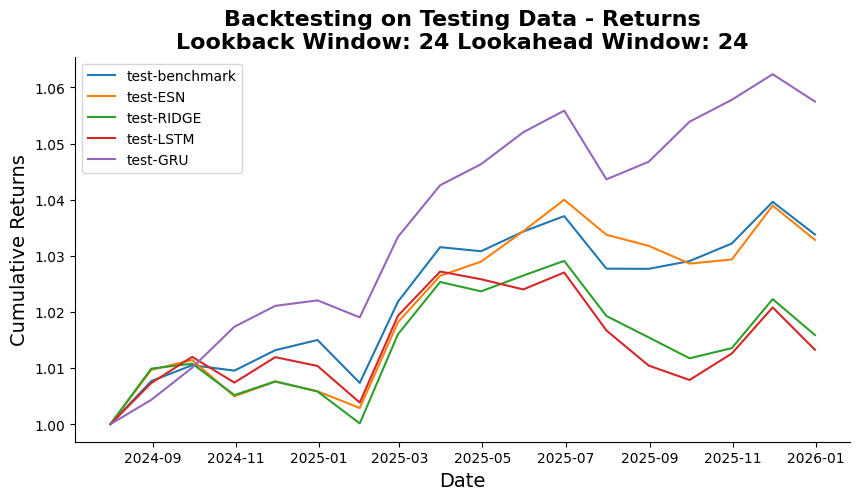

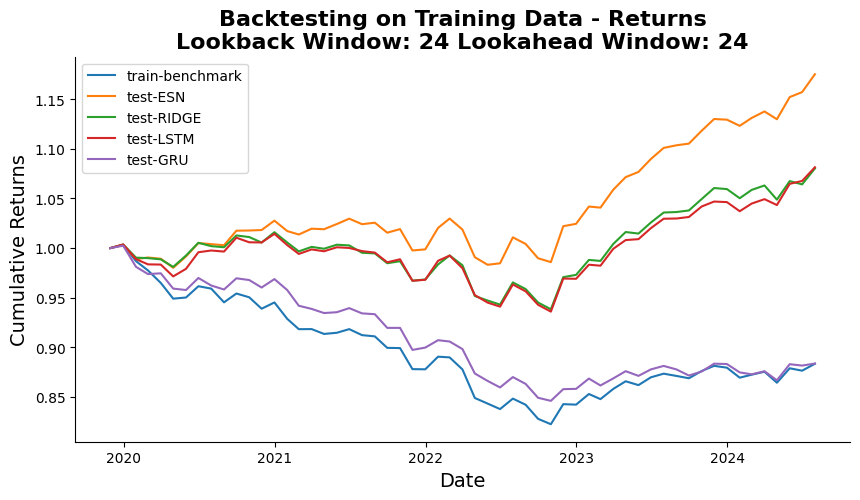

benchmark results for testing data for lookback 24 lookahead 24
          Annualized Return    Annualized Sharpe    Annualized Calmar
------  -------------------  -------------------  -------------------
Actual           0.0237365              1.18535              2.6197
ESN              0.0230664              1.09717              2.11035
RIDGE            0.0111883              0.497476             0.663564
LSTM             0.00934615             0.416638             0.49707
GRU              0.0402317              2.07847              3.47069
benchmark results for training data for lookback 24 lookahead 24
          Annualized Return    Annualized Sharpe    Annualized Calmar
------  -------------------  -------------------  -------------------
Actual           -0.0262108            -0.693324            -0.145616
ESN               0.0352025             0.906638             0.77844
RIDGE             0.0166803             0.444738             0.218217
LSTM              0.0169229          

In [35]:
months = [1, 3, 12, 24]
grid = grid_search_windows(months, months, model_list=['ESN','RIDGE','LSTM', 'GRU'])